# 🧠 Bit Manipulation — Complete Notes
> From zero to advanced. Binary, bitwise ops, shift tricks, and interview patterns.

---

## 📌 Table of Contents
1. [Why Bit Manipulation?](#why)
2. [Binary Number System](#binary)
3. [Decimal ↔ Binary Conversion](#conversion)
4. [One's Complement](#ones)
5. [Two's Complement & Negative Numbers](#twos)
6. [Bitwise Operators](#operators)
7. [Shift Operators](#shifts)
8. [Logical vs Arithmetic Right Shift](#logical-arith)
9. [Get / Set / Clear / Toggle a Bit](#getset)
10. [Common Tricks & Patterns](#tricks)
11. [Practice Problems](#problems)

---
## 1. Why Bit Manipulation? <a id='why'></a>

Everything stored in a computer is ultimately 0s and 1s — bits. Bit manipulation lets you:

- **Speed up** operations (bit ops are O(1) and run at hardware speed)
- **Save memory** (pack multiple flags into a single integer)
- **Solve problems elegantly** that would otherwise need loops or extra space

This shows up constantly in interviews, systems programming, cryptography, graphics, and competitive programming.

---
## 2. Binary Number System <a id='binary'></a>

Computers use **base-2** (binary). Each position represents a power of 2.

```
Position:  7    6    5    4    3    2    1    0
Value:    128   64   32   16    8    4    2    1
```

A single **bit** is 0 or 1. Eight bits = **1 byte**.

| Decimal | Binary |
|---------|--------|
| 0 | 0000 |
| 1 | 0001 |
| 5 | 0101 |
| 13 | 1101 |
| 255 | 1111 1111 |

---
## 3. Decimal ↔ Binary Conversion <a id='conversion'></a>

### Decimal → Binary
Repeatedly divide by 2, collect remainders **bottom to top**.

```
13 / 2 = 6  remainder 1
 6 / 2 = 3  remainder 0
 3 / 2 = 1  remainder 1
 1 / 2 = 0  remainder 1
                       ↑ read upward
Result: 1101
```

### Binary → Decimal
Multiply each bit by 2^(position), sum them up.

```
1101:
  1 x 2^3 = 8
  1 x 2^2 = 4
  0 x 2^1 = 0
  1 x 2^0 = 1
  Total   = 13
```

In [ ]:
# Python built-ins
n = 13
print(f"Decimal {n} -> Binary: {bin(n)}")         # '0b1101'
print(f"Binary '1101' -> Decimal: {int('1101', 2)}")

# Manual decimal to binary
def dec_to_bin(n):
    result = []
    while n > 0:
        result.append(n % 2)
        n //= 2
    return ''.join(map(str, reversed(result))) or '0'

print(f"Manual: {dec_to_bin(13)}")

---
## 4. One's Complement <a id='ones'></a>

**Flip every bit.** 0 -> 1, 1 -> 0.

```
13 in 8-bit:   0000 1101
One's comp:    1111 0010
```

In Python, `~n` computes this, but evaluates to `-(n+1)` due to two's complement:

```python
~13  ->  -14
~0   ->  -1
```

> ⚠️ `~n` feels 'off by one' because Python integers use two's complement with arbitrary precision.

In [ ]:
n = 13
print(f"~{n}    = {~n}")      # -14
print(f"~0     = {~0}")       # -1
print(f"~(-1)  = {~(-1)}")    # 0

---
## 5. Two's Complement & Negative Numbers <a id='twos'></a>

Computers represent **negative numbers** using two's complement:

```
Step 1 - One's complement of 13:
  0000 1101  ->  1111 0010

Step 2 - Add 1:
  1111 0010
+ 0000 0001
----------
  1111 0011   <- This is -13
```

### Why Two's Complement?
- Only one representation of zero (unlike one's complement)
- Addition works the same for positive and negative numbers
- The **MSB** is the sign bit: 0 = positive, 1 = negative

### Range for n-bit signed integers
```
Min: -2^(n-1)       Max: 2^(n-1) - 1
8-bit:  -128 to 127
32-bit: -2,147,483,648 to 2,147,483,647
```

In [ ]:
# -n == ~n + 1  (two's complement negation)
n = 13
print(f"-n via two's complement: {~n + 1}")   # -13

neg_n = ~n + 1
print(f"{n} + ({neg_n}) = {n + neg_n}")        # 0

---
## 6. Bitwise Operators <a id='operators'></a>

These operate **bit by bit** across two integers.

### AND (`&`) — both bits must be 1
```
13: 1 1 0 1
 7: 0 1 1 1
 &: 0 1 0 1  ->  5
```
**Use case:** Masking bits, checking if a bit is set.

### OR (`|`) — at least one bit is 1
```
13: 1 1 0 1
 7: 0 1 1 1
 |: 1 1 1 1  ->  15
```
**Use case:** Setting bits.

### XOR (`^`) — bits differ = 1, same = 0
```
13: 1 1 0 1
 7: 0 1 1 1
 ^: 1 0 1 0  ->  10
```
**XOR Key Properties:**
```
n ^ n  = 0     (cancels itself)
n ^ 0  = n     (identity)
commutative + associative
```

### NOT (`~`) — flip all bits
```
 5: 0000 0101
~5: 1111 1010  ->  -6  (two's complement)
```

In [ ]:
a, b = 13, 7
print(f"{a} in binary: {bin(a)}")
print(f"{b} in binary: {bin(b)}")
print()
print(f"AND  ({a} & {b})  = {a & b}   -> {bin(a & b)}")
print(f"OR   ({a} | {b})  = {a | b}  -> {bin(a | b)}")
print(f"XOR  ({a} ^ {b})  = {a ^ b}  -> {bin(a ^ b)}")
print(f"NOT  (~{a})        = {~a}")

In [ ]:
# XOR properties
n = 42
print(f"{n} ^ {n} = {n ^ n}")   # 0
print(f"{n} ^ 0  = {n ^ 0}")    # 42

# Classic: Find the single non-duplicate in a list
def find_unique(nums):
    result = 0
    for x in nums:
        result ^= x
    return result

print(find_unique([2, 3, 5, 3, 2]))  # 5

---
## 7. Shift Operators <a id='shifts'></a>

### Visual — Left Shift and Right Shift

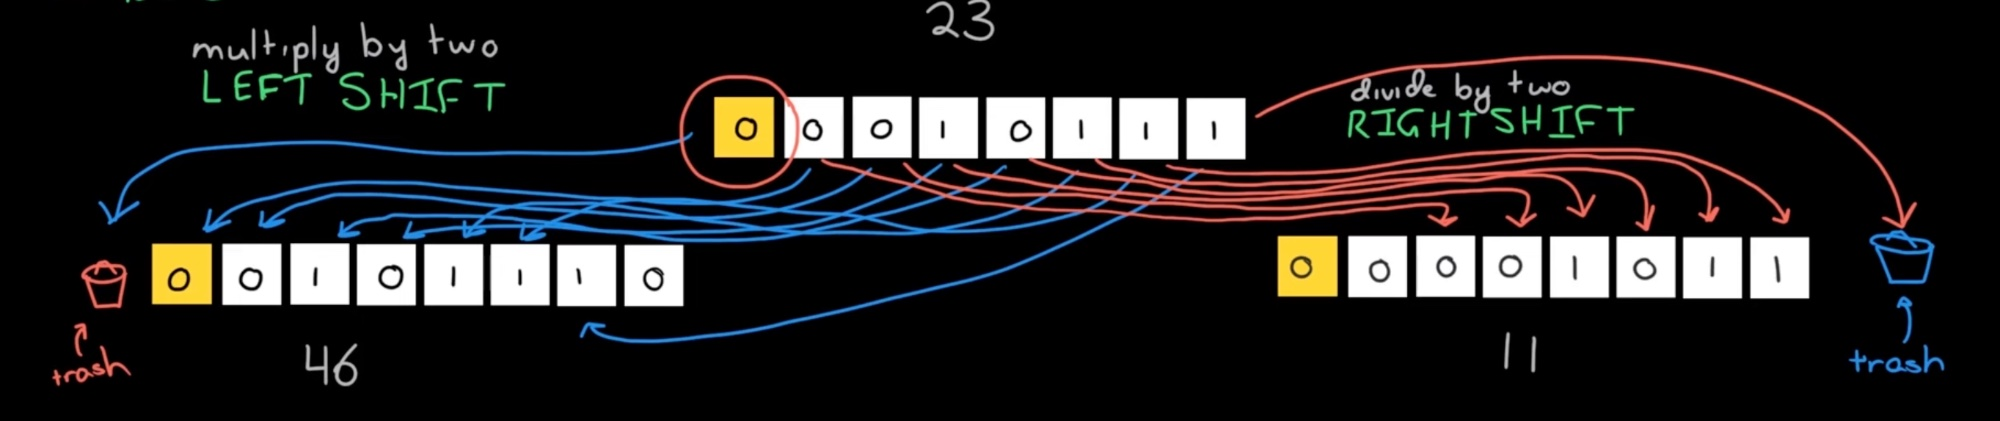

> **LEFT SHIFT (`<<`)** — multiply by 2. Bits move left, 0s fill from the right. MSB falls off.
>
> **RIGHT SHIFT (`>>`)** — divide by 2 (integer). Bits move right. LSB is discarded.

```
23 in binary:   0 0 1 0 1 1 1

23 << 1 = 46:   0 1 0 1 1 1 0   (shifted left, 0 appended right)
23 >> 1 = 11:   0 0 0 1 0 1 1   (shifted right, 0 appended left)
```

**General rules:**
```
n << k  =  n * (2^k)     fast multiply
n >> k  =  n // (2^k)    fast integer divide
```

In [ ]:
n = 23
print(f"{n} in binary: {bin(n)}")
print(f"{n} << 1 = {n << 1}   ({bin(n << 1)})")   # 46
print(f"{n} >> 1 = {n >> 1}   ({bin(n >> 1)})")   # 11
print()
# Powers of 2 via left shift
for k in range(6):
    print(f"1 << {k} = {1 << k}")

---
## 8. Logical vs Arithmetic Right Shift <a id='logical-arith'></a>

### Visual

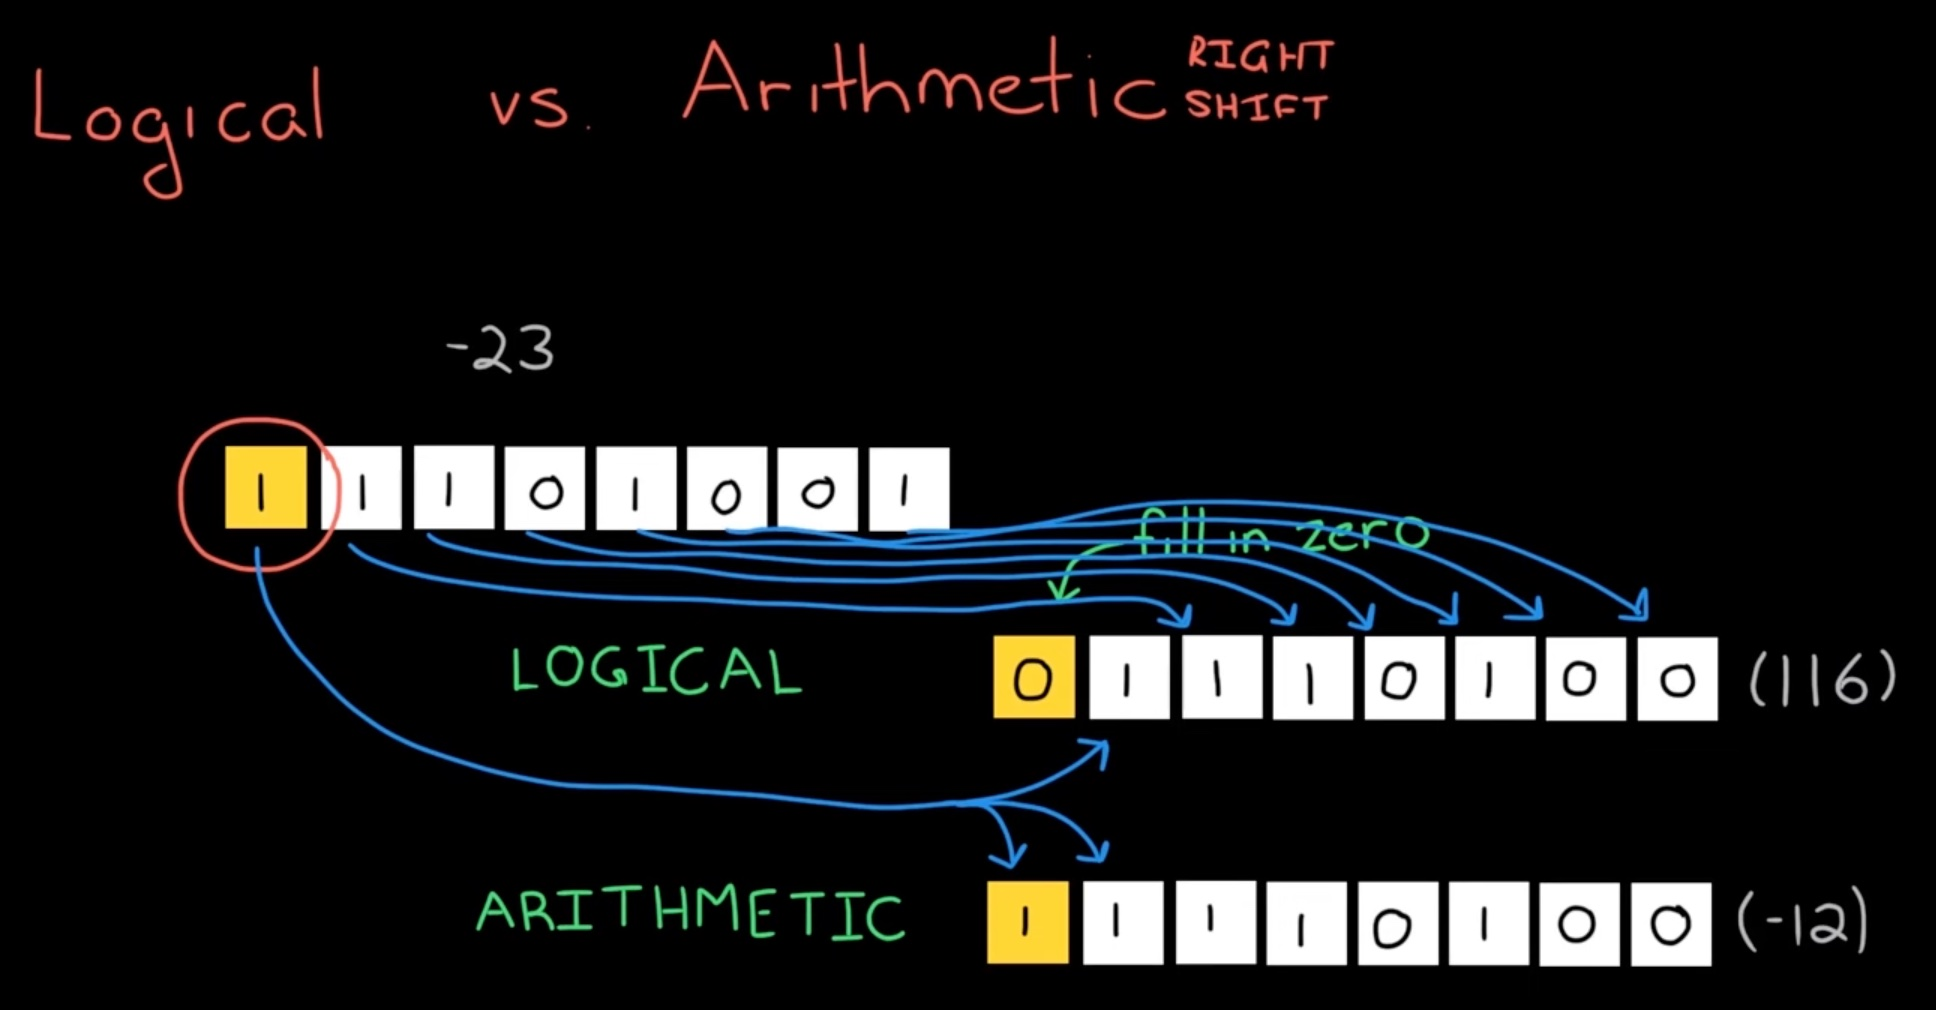

When right-shifting a **negative number**, two behaviours exist:

| Type | Fills left with | Sign preserved? | -23 >> 1 |
|------|-----------------|-----------------|----------|
| **Logical** | Always `0` | No — may go positive | 116 |
| **Arithmetic** | Sign bit (0 or 1) | Yes | -12 |

```
-23 in 8-bit two's complement:  1 1 1 0 1 0 0 1
                                 ^ sign bit = 1

Logical:     0 1 1 1 0 1 0 0  (fills 0)  ->  116  wrong sign
Arithmetic:  1 1 1 1 0 1 0 0  (fills 1)  ->  -12  correct
```

**Python uses arithmetic right shift (`>>`) for negative numbers.**
Java has `>>>` for logical. Python simulation:
```python
(n & 0xFFFFFFFF) >> k   # mask to 32-bit, then shift
```

In [ ]:
n = -23
print(f"{n} >> 1 = {n >> 1}")   # Arithmetic in Python -> -12

def logical_right_shift(n, k, bits=8):
    mask = (1 << bits) - 1
    return (n & mask) >> k

print(f"Logical right shift of {n} by 1: {logical_right_shift(-23, 1)}")  # 116

---
## 9. Get / Set / Clear / Toggle a Bit <a id='getset'></a>

### Visual

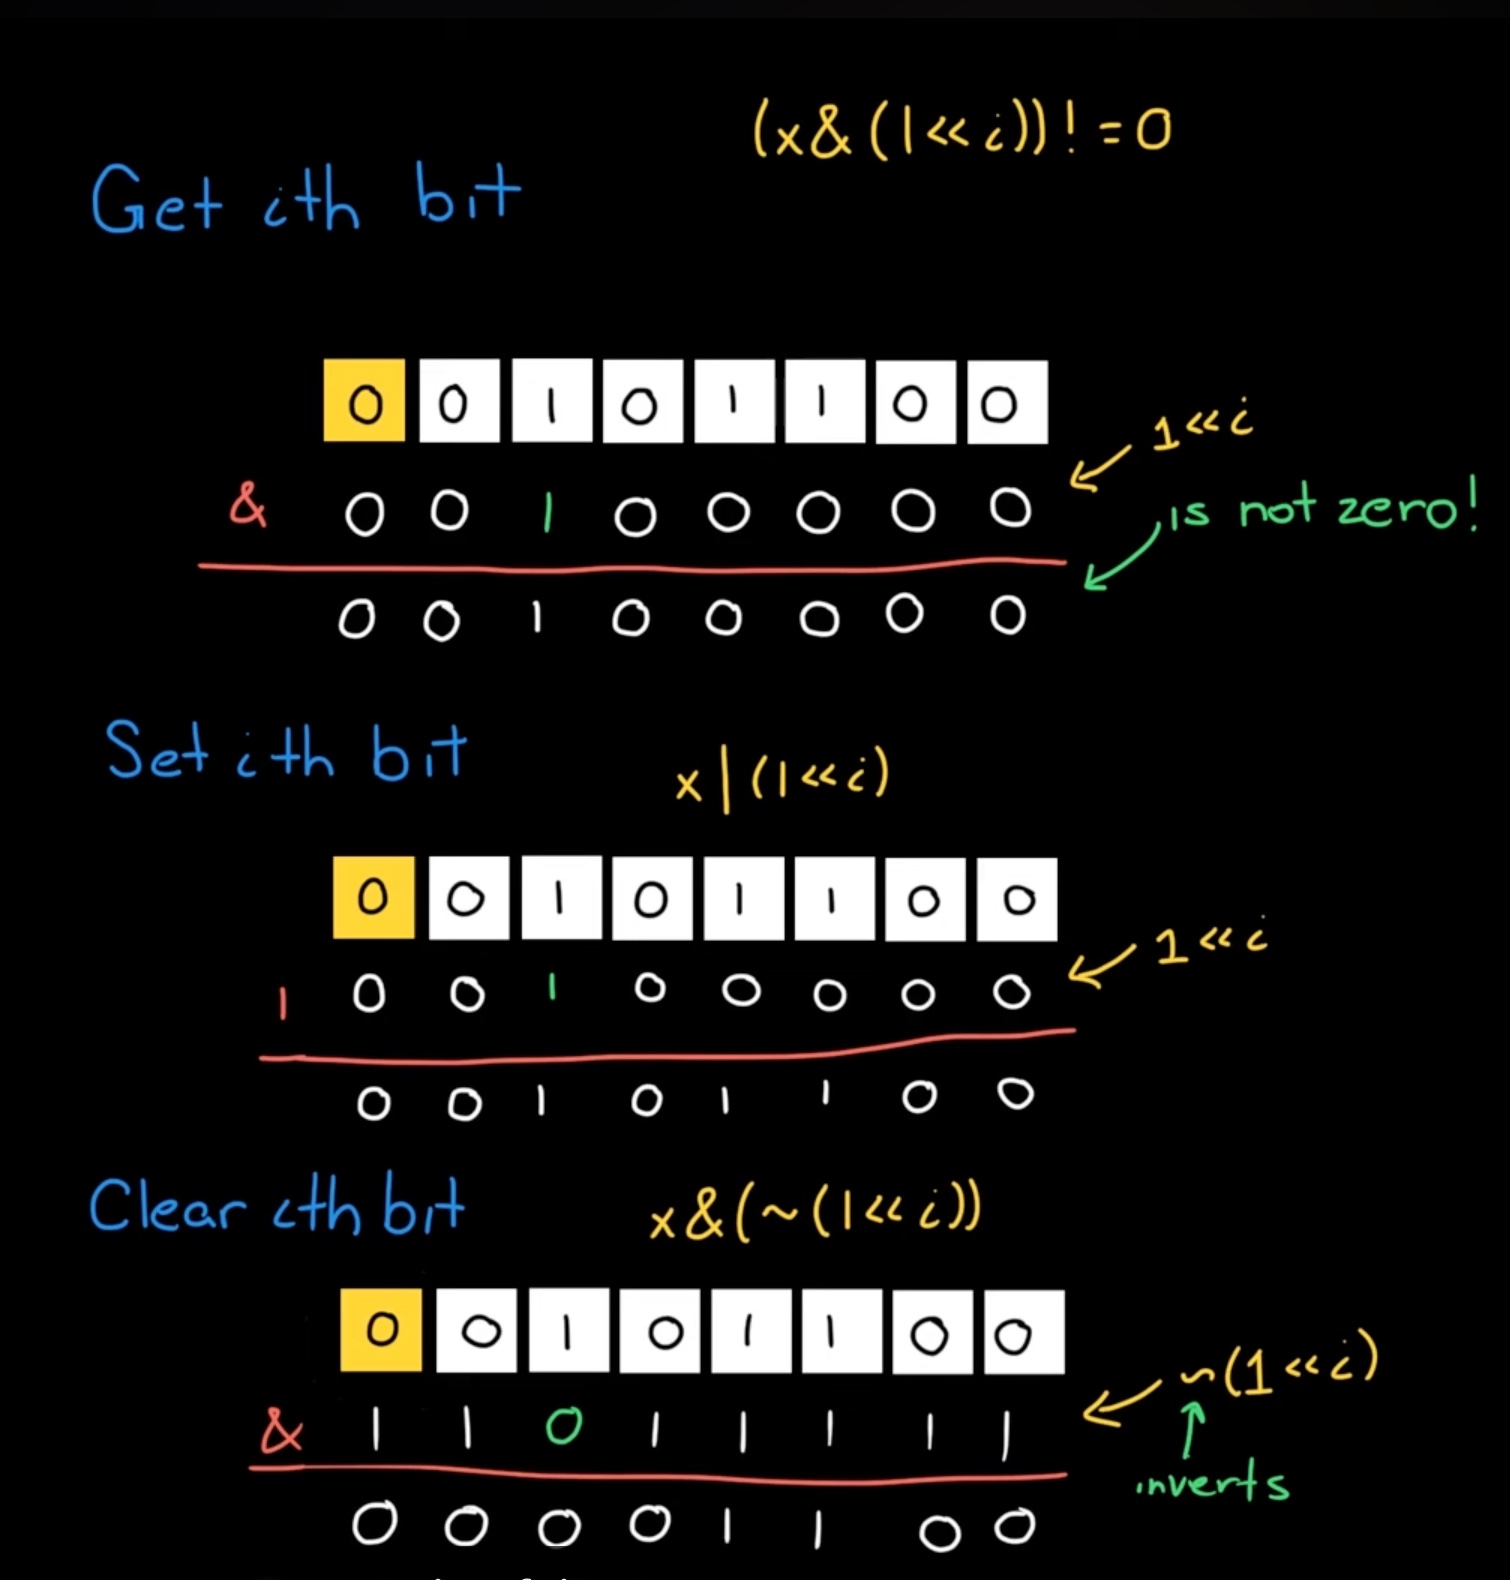

All four operations use `1 << i` as a **mask** — a number with only the i-th bit set.

### Get the i-th bit
```python
(x & (1 << i)) != 0
```
AND with mask. If result is non-zero, bit is set.

### Set the i-th bit (force to 1)
```python
x | (1 << i)
```
OR with mask. Target bit becomes 1, rest unchanged.

### Clear the i-th bit (force to 0)
```python
x & (~(1 << i))
```
Invert the mask (1s everywhere except position i), then AND. Target bit becomes 0.

### Toggle the i-th bit (flip)
```python
x ^ (1 << i)
```
XOR with mask. 1 -> 0, 0 -> 1.

In [ ]:
def get_bit(x, i):    return (x & (1 << i)) != 0
def set_bit(x, i):    return x | (1 << i)
def clear_bit(x, i):  return x & ~(1 << i)
def toggle_bit(x, i): return x ^ (1 << i)

x = 0b01001100  # 76
print(f"x = {x} = {bin(x)}")
print()
print(f"get_bit(x, 2)   = {get_bit(x, 2)}")          # bit 2 = 1 -> True
print(f"get_bit(x, 0)   = {get_bit(x, 0)}")          # bit 0 = 0 -> False
print()
print(f"set_bit(x, 0)   = {bin(set_bit(x, 0))}")     # set bit 0
print(f"clear_bit(x, 2) = {bin(clear_bit(x, 2))}")   # clear bit 2
print(f"toggle_bit(x, 6)= {bin(toggle_bit(x, 6))}")  # toggle bit 6

---
## 10. Common Tricks & Patterns <a id='tricks'></a>

### Trick 1: Check even / odd
```python
n & 1 == 0  ->  even
n & 1 == 1  ->  odd
```

### Trick 2: Swap two numbers (no temp variable)
```python
a = a ^ b
b = a ^ b   # b = (a^b)^b = a
a = a ^ b   # a = (a^b)^a = b
```

### Trick 3: Check if n is a power of 2
```python
n > 0 and (n & (n - 1)) == 0
```
Powers of 2 look like `1000`, `0100`. Subtracting 1 flips all lower bits:
`1000 & 0111 = 0000`

### Trick 4: Clear the lowest set bit
```python
n & (n - 1)
```
Removes the rightmost 1-bit each time. Used in counting set bits.

### Trick 5: Isolate the lowest set bit
```python
n & (-n)
```
Returns only the rightmost 1-bit. Used in Fenwick trees.

### Trick 6: Count set bits — Brian Kernighan's Algorithm
```python
count = 0
while n:
    n &= (n - 1)   # clears lowest set bit
    count += 1
```
O(number of set bits) — much faster than checking all 32/64 positions.

### Trick 7: XOR to find missing number
```python
# Given [0..n] with one missing:
xor = 0
for i in range(n+1): xor ^= i
for x in nums: xor ^= x
# xor is the missing number
```

### Trick 8: Bitmask for subsets
```python
# Enumerate all 2^n subsets of a list
for mask in range(1 << n):
    subset = [nums[i] for i in range(n) if mask & (1 << i)]
```

In [ ]:
# Trick 1: Even / Odd
for n in [4, 7, 12, 15]:
    print(f"{n} is {'even' if n & 1 == 0 else 'odd'}")

In [ ]:
# Trick 2: XOR swap
a, b = 10, 25
print(f"Before: a={a}, b={b}")
a = a ^ b
b = a ^ b
a = a ^ b
print(f"After XOR swap: a={a}, b={b}")

In [ ]:
# Trick 3: Power of 2
def is_power_of_two(n):
    return n > 0 and (n & (n - 1)) == 0

for n in [1, 2, 3, 4, 16, 18, 32]:
    print(f"{n}: {is_power_of_two(n)}")

In [ ]:
# Trick 6: Count set bits (Kernighan)
def count_set_bits(n):
    count = 0
    while n:
        n &= (n - 1)
        count += 1
    return count

for n in [7, 13, 255, 1024]:
    print(f"{n} ({bin(n)}) -> {count_set_bits(n)} set bits")

In [ ]:
# Trick 5: Isolate lowest set bit
n = 0b101100   # 44
lowest = n & (-n)
print(f"n        = {bin(n)}")
print(f"n & (-n) = {bin(lowest)}  ({lowest})")  # rightmost 1-bit

---
## 11. Practice Problems <a id='problems'></a>

| Problem | Key Technique |
|---------|---------------|
| Single Number (LC 136) | XOR all elements |
| Number of 1 Bits (LC 191) | Kernighan's `n &= (n-1)` |
| Power of Two (LC 231) | `n & (n-1) == 0` |
| Reverse Bits (LC 190) | Shift + OR loop |
| Counting Bits (LC 338) | DP + `n & (n-1)` |
| Missing Number (LC 268) | XOR 0..n with array |
| Sum of Two Integers (LC 371) | XOR for sum, AND+shift for carry |
| Single Number II (LC 137) | Bit counting mod 3 |
| Subsets (LC 78) | Bitmask enumeration |

---
## Quick Reference Cheatsheet

| Operation | Code | Notes |
|-----------|------|-------|
| Check i-th bit | `(x >> i) & 1` | 1 if set |
| Set i-th bit | `x | (1 << i)` | Force to 1 |
| Clear i-th bit | `x & ~(1 << i)` | Force to 0 |
| Toggle i-th bit | `x ^ (1 << i)` | Flip |
| Is even? | `n & 1 == 0` | — |
| Is power of 2? | `n & (n-1) == 0` | Also n > 0 |
| Count set bits | `n &= (n-1)` loop | Kernighan |
| Lowest set bit | `n & (-n)` | — |
| Clear lowest bit | `n & (n-1)` | — |
| Multiply by 2^k | `n << k` | — |
| Divide by 2^k | `n >> k` | Arithmetic in Python |
| Negate | `~n + 1` | Two's complement |
| XOR swap | `a^=b; b^=a; a^=b` | No temp var |